# Ch 14: NLP w/ RNNs + Attention

NLP used to be dominated by RNNs, now transformers dominate, but SSMs, space state models, are making a comeback.

## Generating Shakespere w/ Character RNN

### Creating the Training Dataset

In [1]:
from pathlib import Path
import urllib.request

def download_shakespeare_text():
    path = Path("datasets/shakespeare/shakespeare.txt")
    if not path.is_file():
        path.parent.mkdir(parents=True, exist_ok=True)
        url = "https://homl.info/shakespeare"
        urllib.request.urlretrieve(url, path)
    return path.read_text()

shakespeare_text = download_shakespeare_text()
print(shakespeare_text[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


Step 1: turn text into numbers. Usually this is done by splitting words/characters into tokens and tokenizing, assigning an ID to every possible token

To reduce size, use lowercase only:

In [2]:
vocabulary = sorted(set(shakespeare_text.lower()))

# and also make a convenient way to convert

char_to_id = {char: index for index,char in enumerate(vocabulary)}
id_to_char = {index: char for index,char in enumerate(vocabulary)}

char_to_id["k"]

23

In [3]:
# The same thing, but with torch tensors
import torch

def encode_text(text):
    return torch.tensor([char_to_id[char] for char in text.lower()])

def decode_text(ids):
    return "".join([id_to_char[id.item()] for id in ids])

encoded = encode_text("Hello World")
decoded = decode_text(encoded)
decoded

'hello world'

In [4]:
# Prepping our dataset
from torch.utils.data import DataLoader, Dataset

class CharDataset(Dataset):
    def __init__(self, text, window_length):
        self.encoded_text = encode_text(text)
        self.window_length = window_length

    def __len__(self):
        return len(self.encoded_text) - self.window_length
    
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError
        end = idx + self.window_length
        window = self.encoded_text[idx:end]
        target = self.encoded_text[idx+1:end+1] # Target is window shifted one right
        return window, target

In [5]:
window = 50
batch_size = 256
train_set = CharDataset(shakespeare_text[:1_000_000], window)
valid_set = CharDataset(shakespeare_text[1_000_000:1_060_000], window)
test_set = CharDataset(shakespeare_text[1_060_000:], window)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

Neural nets come with the underlying assumption that closer number = better. In this case, that doesn't work, since "a" is not necessarily closer to "b" than "i" when trying to guess the next letter of a word. 

You could OHE -> but that explodes data size for big vocabularies

Instead: embed

### Embeddings

An embedding is a dense representation of higher-dim data, usually a cat feature. High number of possible categories causes OHE to produce huge vector, while embedding will produce a smaller vector. 

Usually make embedding size = root n_categories

For DL, embeddings can be initialized randomly, then trained via gradient descent.

Hopefully after training, similar categories are closer together, and unrelated concepts are far apart. This is representation learning

Embeddings can be reused for other tasks -> usually better to get someone elses trained embedding than using your own

Embeddings can be organized along useful axes. For ex, the embeddings of King - Man + Woman roughly equal the embedding of Queen. 

Pytorch has nn.Embedding, a wrapped of a matrix with one row per category, and one col per embedding dimension. To get the embedding, it just looks up whatever row you want.

In [6]:
import torch.nn as nn

torch.manual_seed(22)
embed = nn.Embedding(5,3) 
embed(torch.tensor([[3,2],[0,2]]))
# so cat 3 is embedded as [1.3164, -0.8576, -0.3336]

tensor([[[ 1.3164, -0.8576, -0.3336],
         [ 0.7240,  0.2416, -1.5601]],

        [[ 1.0302, -0.5073, -0.1017],
         [ 0.7240,  0.2416, -1.5601]]], grad_fn=<EmbeddingBackward0>)

An embedding layer is the same as OHE followed by a linear layer (w/o bias): You are just multiplying the OHE vector by the embedding matrix, but you dont have to do a bunch of multiplications by 0

### Building and Training Char-RNN

Large dataset, need some complexity, so probably need GRU instead of a simple RNN

In [7]:
class ShakespeareModel(nn.Module):
    def __init__(self, vocab_size, n_layers=2, embed_dim=10, hidden_dim=128, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim) # encodes character IDs. you can tune embedding dim
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout) #need to set batch first, otherwise layer assumes batch dim after time dim
        self.output = nn.Linear(hidden_dim, vocab_size) # needs one output per distinct char

    def forward(self, X):
        embeddings = self.embed(X)
        outputs, _states = self.gru(embeddings)
        return self.output(outputs).permute(0,2,1) # cross entropy and accuracy expect batch size, class, window length
                                                 # but linear will output batch size, window length, vocab size since GRU outputs batch, window, hidden
    
device = "cuda"
model = ShakespeareModel(len(vocabulary)).to(device)

In [8]:
# !pip install torchmetrics
import torchmetrics
loss = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=len(vocabulary)).to(device)
optim = torch.optim.AdamW(model.parameters())

def train(model, dataloader, loss_fn, metric, optim, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        epoch_stats = []
        for X_train, y_train in dataloader:
            X_train = X_train.to(device)
            y_train = y_train.to(device)
            y_hat = model(X_train)
            loss = loss_fn(y_hat,y_train)
            optim.zero_grad()
            loss.backward()
            optim.step()
            epoch_stats.append(metric(y_hat,y_train))
        print(epoch, sum(epoch_stats)/len(epoch_stats))

train(model, train_loader, loss, metric, optim, 1)

/home/will/Desktop/ML_notes/MLNotes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0 tensor(0.5174, device='cuda:0')


In [9]:
# got ~58% with 7 epochs
model.eval()  
text = "That is the mod"
encoded_text = encode_text(text).unsqueeze(dim=0).to(device)
with torch.no_grad():
    Y_logits = model(encoded_text)
    predicted_char_id = Y_logits[0, :, -1].argmax().item()
    predicted_char = id_to_char[predicted_char_id]

predicted_char

'e'

### Generating Text

Greedy decoding: model predicts next character, then you feed the input+predicted char back into the model. In practice, leads to high repetition

Instead, pick the next character randomly: if the model predicts "e" follows "To be or not to b" with p=.9 and k with p=.1, we randomly select e or k.

In [10]:
probs = torch.tensor([[.5,.4,.1]])
torch.multinomial(probs, replacement=True, num_samples=10)
#will pick 0 or 1 most of the time since they have the highest weights

tensor([[2, 2, 1, 0, 1, 2, 1, 0, 0, 1]])

Add control by dividing logits by a new parameter, temperature. High temperature = more random, and low temp = less random. 

In [11]:
import torch.nn.functional as F

def next_char(model, text, temperature=1):
    encoded_txt = encode_text(text).unsqueeze(dim=0).to(device) #unsqueeze adds a batch dim
    with torch.no_grad():
        Y_logits = model(encoded_txt)
        Y_probas = F.softmax(Y_logits[0,:,-1] / temperature, dim=-1) # 0 drops batch dim, -1 grabs logits
                                                                    # and softmax converts to probas
        pred_id = torch.multinomial(Y_probas, num_samples=1).item()
    return id_to_char[int(pred_id)]

def extend_text(model, text, n_chars=80, temperature=1):
    for _ in range(n_chars):
        text+=next_char(model, text, temperature)
    return text

print(extend_text(model, "To be or not to b", temperature=.9))

To be or not to be issue to do not
welcome of companiage; thy other provpemined: you'll keep in o


You could also try only sampling the top few predicted probability characters (top k), or use beam search, or adding more GRU layers, or increasing neurons, or training for longer.

Notably, very large RNNs can learn something similar to sentiment analysis, like for the sentence "That movie was great, I really ", it predicts L (liked, loved) is way more likely than H (hated). 

## Sentiment Analysis w/ HuggingFace Libraries

In [12]:
from datasets import load_dataset

imdb_dataset = load_dataset("imdb")
split = imdb_dataset["train"].train_test_split(train_size=0.8, seed=42)
imdb_train_set, imdb_valid_set = split["train"], split["test"]
imdb_test_set = imdb_dataset["test"]

In [13]:
imdb_train_set[0]["text"]

'Stage adaptations often have a major fault. They often come out looking like a film camera was simply placed on the stage (Such as "Night Mother"). Sidney Lumet\'s direction keeps the film alive, which is especially difficult since the picture offered him no real challenge. Still, it\'s nice to look at for what it is. The chemistry between Michael Caine and Christopher Reeve is quite brilliant. The dynamics of their relationship are surprising. Caine is fantastic as always, and Reeve gets one of his few chances to really act.<br /><br />I confess that I\'ve never seen Ira Levin\'s play, but I hear that Jay Presson Allen\'s adaptation is faithful. The script is incredibly convoluted, and keeps you guessing. "Deathtrap" is an enormously entertaining film, and is recommended for nearly all fans of stage and screen.<br /><br />7.4 out of 10'

This example is somewhat difficult, it starts off by talking about difficulties and "major fault". Still, it's a positive review.

We need to tokenize instead of going char-by-char

### Tokenization w/ HF Tokenizers Library

Split words into tokens: smartest becomes "smart" and "est". How? One way is byte pair encoding, BPE. Split your training set into individual characters, then at each iteration find the most frequent pair of adjacent tokens and add it to the vocab.

In [14]:
import tokenizers

bpe_model = tokenizers.models.BPE(unk_token="<unk>") #if token is unknown, replace it w/ unk
bpe_tokenizer = tokenizers.Tokenizer(bpe_model)
bpe_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.Whitespace() #splits text at spaces, and separates letters/nonletters
special_tokens = ["<pad>", "<unk>"]
bpe_trainer = tokenizers.trainers.BpeTrainer(vocab_size=1000, special_tokens=special_tokens)
train_reviews = [review["text"].lower() for review in imdb_train_set]
bpe_tokenizer.train_from_iterator(train_reviews, bpe_trainer)

In [15]:
review_1 = "that movie was sooooooo sick%"
bpe_tokenizer.encode(review_1).tokens
# tokenizer recognizes "that" and "movie", but not "sick" or "sooooooo"

['that', 'movie', 'was', 'so', 'o', 'o', 'o', 'o', 'o', 'o', 's', 'ick', '%']

In [16]:
token_ids = bpe_tokenizer.encode(review_1).ids
bpe_tokenizer.decode(token_ids)
# get_vocab() returns a token-to-id dictionary

'that movie was so o o o o o o s ick %'

In [17]:
bpe_tokenizer.encode(review_1).offsets
# helpful for debugging where your tokenizer is messing up

[(0, 4),
 (5, 10),
 (11, 14),
 (15, 17),
 (17, 18),
 (18, 19),
 (19, 20),
 (20, 21),
 (21, 22),
 (22, 23),
 (24, 25),
 (25, 28),
 (28, 29)]

In [18]:
bpe_tokenizer.enable_padding(pad_id=0, pad_token="<pad>")
bpe_tokenizer.enable_truncation(max_length=500)
# to create a tensor, we need to have consistent dims, which means padding+truncation needed

In [19]:
encodings = bpe_tokenizer.encode_batch(train_reviews[:3])
bpe_batch_ids = torch.tensor([encoding.ids for encoding in encodings])

Every Encoding object (which encode_batch returns) has an attention_mask attribute, this can be used to tell your model what to ignore easily by multiplying

Or you could get the sequence lengths themselves

In [20]:
attn_mask = torch.tensor([encoding.attention_mask for encoding in encodings])
lengths = attn_mask.sum(dim=-1)

Spaces don't really work with our tokenizer, it ends up just putting spaces between every token because Whitespace gets rid of the spaces

Instead, use ByteLevel pre-tokenizer, which replaces the spaces with their own special character

ByteLevel works at the byte level, not character level, using UTF-8 encoding. There are only 256 possible bytes, so BBPE works well for long tokens not found in the vocabulary

WordPiece, a BPE variant, works by adding the pair of adjacent tokens with the highest score. The score boosts frequent pairs, but normalizes by how many times the individual tokens show up. So "the" is a very common word, but "the ----" probably doesn't need its own token. WordPiece favors more useful/meaningful tokens, and shortens the encoding sequence

Wordpiece Score Formula (for tokens A, B): $\frac{frequency(AB)}{freq(A)\cdot freq(B)} \cdot len(vocab)$

To train w/ Tokenizers library, use same code as above, but replace "BPE" model w/ WordPiece

Another tokenizer algo: UnigramLM. Starts with a vocabulary of every possible word, subword, and character in your text corpus, and then removes the least useful ones until you get the size you want. Assumes that the corpus was sampled randomly from your vocabulary, each token independent from others, so P(AB)=P(A)P(B). It can then estimate P(sampling this corpus), and remove tokens that do not reduce P(sampling this corpus) too much. UnigramLM is good for languages that don't use spaces

^ same paper into'd Subword Regularization, which improves generalization by intro'ing randomness in tokenization during NLP model training. Assume your vocabulary has: "them", "the", "m" tokens. Sometimes you will tokenize "them" as "them", sometimes "the"+"m". If a language carries a lot of info through grammatical modifications/affixes, this method can help. 

| Feature | BBPE | WordPiece | Unigram LM |
|---------|------|-----------|------------|
| **How** | Merge most frequent pairs | Merge pairs that maximize data likelihood | Remove least likely tokens |
| **Pros** | Fast, simple, great for multilingual | Good balance of efficiency and token quality | Most meaningful, shortest sequences |
| **Cons** | Can produce awkward splits | Less robust than BBPE for multilingual | Slower to train and tokenize |
| **Used By** | GPT, Llama, RoBERTa, BLOOM | BERT, DistilBERT, ELECTRA | T5, ALBERT, mBART |

Generally: best to use a pretrained tokenizer

If you have a lot of domain specific info, or a language without a lot of resources available on it, you may want to consider training your own tokenizer.

### Reusing Pretrained Tokenizers

HF transformers library can get you tokenizers as well as transformer models, cnns, various neural nets

In [21]:
import transformers

gpt2_tokenizer = transformers.AutoTokenizer.from_pretrained("gpt2")
gpt2_encoding = gpt2_tokenizer(train_reviews[:3], truncation=True, max_length=500)
gpt2_encoding["input_ids"][0][:5] # get first 5 tokens of first review

[14247, 35030, 1690, 423, 257]

In [22]:
gpt2_tokenizer.decode(gpt2_encoding["input_ids"][0][:10])

'stage adaptations often have a major fault. they often'

In [23]:
gpt2_tokenizer("malformations")

{'input_ids': [7617, 687, 602], 'attention_mask': [1, 1, 1]}

If you want a WordPiece tokenizer, you need to get a tokenizer from a model pretrained w/ wordpiece, like BERT

This tokenizer has a padding token and lets us get pytorch tensors

In [24]:
bert_tokenizer = transformers.AutoTokenizer.from_pretrained("bert-base-uncased")
bert_encoding = bert_tokenizer(train_reviews[:3], padding=True,
                               truncation=True, max_length=500,
                               return_tensors="pt")

# bert_encoding["input_ids"] # now there is padding, and attn masks in ["attention_mask"]

### Building and Training a Sentiment Analysis Model

To tokenize your text data, you can pass a function to the DataLoader w/ the collate_fn arg. Your function needs to take in a batch, tokenize, truncate and pad if needed, and return a BatchEncoding object (that holds token ids, attn masks, labels)

In [25]:
def collate_fn(batch, tokenizer=bert_tokenizer):
    reviews = [review["text"] for review in batch]
    labels = [[review["label"]] for review in batch]
    encodings = tokenizer(reviews, padding=True, truncation=True, max_length=200, return_tensors="pt") #pytorch
    labels = torch.tensor(labels, dtype=torch.float32)
    return encodings, labels

batch_size = 256
train_loader = DataLoader(imdb_train_set, batch_size=batch_size, collate_fn=collate_fn, shuffle=True)
valid_loader = DataLoader(imdb_valid_set, batch_size=batch_size, collate_fn=collate_fn)
test_loader = DataLoader(imdb_test_set, batch_size=batch_size, collate_fn=collate_fn)

In [26]:
class SentimentAnalysisModel(nn.Module):
    def __init__(self, vocab_size, n_layers=2, embed_dim=128, hidden_dim=64, pad_id=0, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id) #need to tell embedding what the padding idx is so it knows not to train it
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_dim, 1) #binary classification

    def forward(self, encodings): # takes in a batchencoding object
        embeddings = self.embed(encodings["input_ids"])
        _outputs, hidden_states = self.gru(embeddings)
        return self.output(hidden_states[-1]) # this is sequence-to-vector, so only output top GRU layer

In [27]:
# Let's train!

vocabulary_len = bert_tokenizer.vocab_size
model = SentimentAnalysisModel(vocab_size=vocabulary_len).to(device)
loss = nn.BCEWithLogitsLoss()
metric = torchmetrics.Accuracy(task="binary").to(device)
optim = torch.optim.AdamW(model.parameters())

train(model, train_loader, loss, metric, optim, 3)

0 tensor(0.5106, device='cuda:0')
1 tensor(0.5804, device='cuda:0')
2 tensor(0.6341, device='cuda:0')


In [28]:
model.eval()  
text = "This movie was meh. 4/10"
tokens = bert_tokenizer(text, return_tensors="pt").to(device)
with torch.no_grad():
    display(torch.sigmoid(model(tokens)))

tensor([[0.2124]], device='cuda:0')

One issue with this model: does not fully ignore padding tokens, they still get processed by the GRU. 

Can use a "packed sequence", which is a data structure that efficiently represents variable length sequences, as a tensor.

In [29]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
sequences = torch.tensor([[1,2,0,0],[4,6,7,8]])
packed = pack_padded_sequence(sequences, lengths=(2,4), enforce_sorted=False, batch_first=True)
pad_packed_sequence(packed)

(tensor([[1, 4],
         [2, 6],
         [0, 7],
         [0, 8]]),
 tensor([2, 4]))

Assumes sequences are ordered longest to shortest, which means you have to use enforce_sorted=False. If batch dim is first, must use batch_first=True

In [30]:
# to handle packed sequences:
class SentimentAnalysisModel(nn.Module):
    def __init__(self, vocab_size, n_layers=2, embed_dim=128, hidden_dim=64, pad_id=0, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id) 
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_dim, 1) 

    def forward(self, encodings): 
        embeddings = self.embed(encodings["input_ids"])
        lengths = encodings["attention_mask"].sum(dim=1) # get sequence lengths
        packed = pack_padded_sequence(embeddings, lengths=lengths.cpu(), batch_first=True, enforce_sorted=False) 
        _outputs, hidden_states = self.gru(packed)
        return self.output(hidden_states[-1])

### Bidirectional RNNs

Causal: only look into present and past inputs. For time series or seq2seq decoders. But for text classification / encoders, might be useful to look into the future before encoding a certain word. Context is important.

Most pytorch RNN modules have a bidirectional=True argument. You need to double nn.Linear input size, since you are doubling hidden state size, and you also need to concatenate forward/backward hidden states of the GRU top layer.

In [31]:
class BidirectionalSentModel(nn.Module):
    def __init__(self, vocab_size, n_layers=2, embed_dim=128, hidden_dim=64, pad_id=0, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id) 
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.output = nn.Linear(hidden_dim*2, 1) 

    def forward(self, encodings): 
        embeddings = self.embed(encodings["input_ids"])
        lengths = encodings["attention_mask"].sum(dim=1)
        packed = pack_padded_sequence(embeddings, lengths=lengths.cpu(), batch_first=True, enforce_sorted=False) 
        _outputs, hidden_states = self.gru(packed)
        # GRU goes from 2,256,64 -> 4,256,64
        # where 256 is the batch, 64 is the hidden size
        # Forward Layer 1, Backward Layer 1, Forward Layer 2, Backward Layer 2
        n_dims = self.output.in_features
        top_states = hidden_states[-2:].permute(1,0,2).reshape(-1,n_dims)
        # this takes a [2,256,64] tensor, reshapes to [256,128]
        # now our output takes the forward and backward passes for the top layer
        return self.output(top_states)

### Reusing Pretrained Embeddings and Language Models
Context is generally similar across tasks, so reusing an embedding someone made on a billion tokens is better than one you trained on 100k.

In [32]:
bert_model = transformers.AutoModel.from_pretrained("bert-base-uncased")
embeddings = bert_model.embeddings.word_embeddings

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19082.45it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
class SentimentAnalysisBertEmbeds(nn.Module):
    def __init__(self, pretrained_embeds, n_layers=2, hidden_dim=64, dropout=0.2):
        super().__init__()
        weights = pretrained_embeds.weight.data
        self.embed = nn.Embedding.from_pretrained(weights, freeze=True)
        embed_dim = weights.shape[-1]
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.output = nn.Linear(hidden_dim*2, 1) 

    def forward(self, encodings): 
        embeddings = self.embed(encodings["input_ids"])
        lengths = encodings["attention_mask"].sum(dim=1)
        packed = pack_padded_sequence(embeddings, lengths=lengths.cpu(), batch_first=True, enforce_sorted=False) 
        _outputs, hidden_states = self.gru(packed) 
        n_dims = self.output.in_features
        top_states = hidden_states[-2:].permute(1,0,2).reshape(-1,n_dims)
        return self.output(top_states)

In [34]:
model = SentimentAnalysisBertEmbeds(embeddings).to(device)
loss = nn.BCEWithLogitsLoss()
metric = torchmetrics.Accuracy(task="binary").to(device)
optim = torch.optim.AdamW(model.parameters())

train(model, train_loader, loss, metric, optim, 3)

0 tensor(0.5742, device='cuda:0')
1 tensor(0.7162, device='cuda:0')
2 tensor(0.7615, device='cuda:0')


In [35]:
# To unfreeze the embedding weights and tell the optimizer about them

# for param in model.embed.parameters():
#     param.requires_grad=True
# optim.add_param_group({"params":model.embed.parameters()})

In [36]:
# What if we just want to reuse the whole bert model to do sentiment analysis?

class SentimentAnalysisModelBert(nn.Module):
    def __init__(self, n_layers=2, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.bert = transformers.AutoModel.from_pretrained("bert-base-uncased")
        embed_dim = self.bert.config.hidden_size
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout)
        # dont need bidirectional, the "contextualized embeddings" already look ahead
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, encodings):
        contextualized_embeddings = self.bert(**encodings).last_hidden_state
        lengths = encodings["attention_mask"].sum(dim=1)
        packed = pack_padded_sequence(contextualized_embeddings, lengths=lengths.cpu(), batch_first=True, enforce_sorted=False) 
        _outputs, hidden_states = self.gru(packed)
        return self.output(hidden_states[-1])

Or you could use the contextualized embedding for the first token, the class token [CLS]. This is a classification embedding the BERT model learned during training, and you can just get rid of the GRU and use this embedding instead, since its a decent sentiment embedding.

Just grab bert_output.last_hidden_state[:,0]

### Task-Specific Classes

bert has a pretrained model for classification, just bert + classification head

In [37]:
from transformers import BertForSequenceClassification

bert_for_bclf = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to(device)
# HF treats binary as multiclass, so two outputs. Need to use Cross Entropy Loss and Softmax instead of BCE and Sigmoid

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 20921.58it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider t

In [38]:
tokens = bert_tokenizer(["This movie was awesome"])
with torch.no_grad():
    output = bert_for_bclf(input_ids=torch.tensor(tokens["input_ids"], device=device), attention_mask = torch.tensor(tokens["attention_mask"], device=device))
torch.softmax(output.logits, dim=-1)
# The classification head is not pretrained - obvious from below

tensor([[0.5509, 0.4491]], device='cuda:0')

### Trainer API

This lets you fine tune a model easily, with checkpoints, early stopping, tensor parallelism, metrics, etc.

Handles padding/batching/shuffling. 

Takes in Dataset objects, and expects tokenized text.

In [39]:
def tokenize_batch(batch):
    return bert_tokenizer(batch["text"], truncation=True, max_length=200)

tok_imdb_train_set = imdb_train_set.map(tokenize_batch, batched=True)
tok_imdb_valid_set = imdb_valid_set.map(tokenize_batch, batched=True)
tok_imdb_test_set = imdb_test_set.map(tokenize_batch, batched=True)

def compute_accuracy(pred):
    predictions = pred.predictions.argmax(-1)
    return {"accuracy": (predictions == pred.label_ids).mean()}

In [ ]:
from transformers import TrainingArguments, DataCollatorWithPadding, Trainer
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
train_args = TrainingArguments(
    output_dir="imdb_model", num_train_epochs=1,
    per_device_train_batch_size=32, per_device_eval_batch_size=32,
    eval_strategy="epoch", logging_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="accuracy",
    report_to="none", fp16=True)

trainer = Trainer(bert_for_bclf, train_args, train_dataset=tok_imdb_train_set,
                  eval_dataset=tok_imdb_valid_set, compute_metrics=compute_accuracy,
                  data_collator=DataCollatorWithPadding(bert_tokenizer))

# train_output = trainer.train()
# gets ~90% accuracy in 2mins

/home/will/Desktop/ML_notes/MLNotes/.venv/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:45: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  if warn_imbalance(lambda props: props.total_memory):
/home/will/Desktop/ML_notes/MLNotes/.venv/lib/python3.12/site-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,0.613664,0.481547,0.903600


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.54it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

### Hugging Face Pipelines

Transformers library lets you download/use pretrained pipelines, which have preprocessing/postprocessing parts

In [42]:
from transformers import pipeline

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
classifier_imdb = pipeline("sentiment-analysis", model=model_name,
                            truncation=True, max_length=512)

classifier_imdb(train_reviews[:10])

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6842.37it/s]


[{'label': 'POSITIVE', 'score': 0.9996108412742615},
 {'label': 'POSITIVE', 'score': 0.9998623132705688},
 {'label': 'NEGATIVE', 'score': 0.9943684935569763},
 {'label': 'POSITIVE', 'score': 0.997913658618927},
 {'label': 'POSITIVE', 'score': 0.999544084072113},
 {'label': 'NEGATIVE', 'score': 0.9845332503318787},
 {'label': 'POSITIVE', 'score': 0.9859278202056885},
 {'label': 'POSITIVE', 'score': 0.9993758797645569},
 {'label': 'POSITIVE', 'score': 0.9978922009468079},
 {'label': 'NEGATIVE', 'score': 0.9997020363807678}]

Note: be careful when selecting the options for pipelines. If you dont specify, itll be defaults, so you should look up exactly which model to use.

There is a lot of model bias - especially towards countries and places, that comes from the training. I.e Iraq is associated with war, so "I am from Iraq" is negative classified. You can help this by adding a neutral class.

## Encoder-Decoder Network for MTL
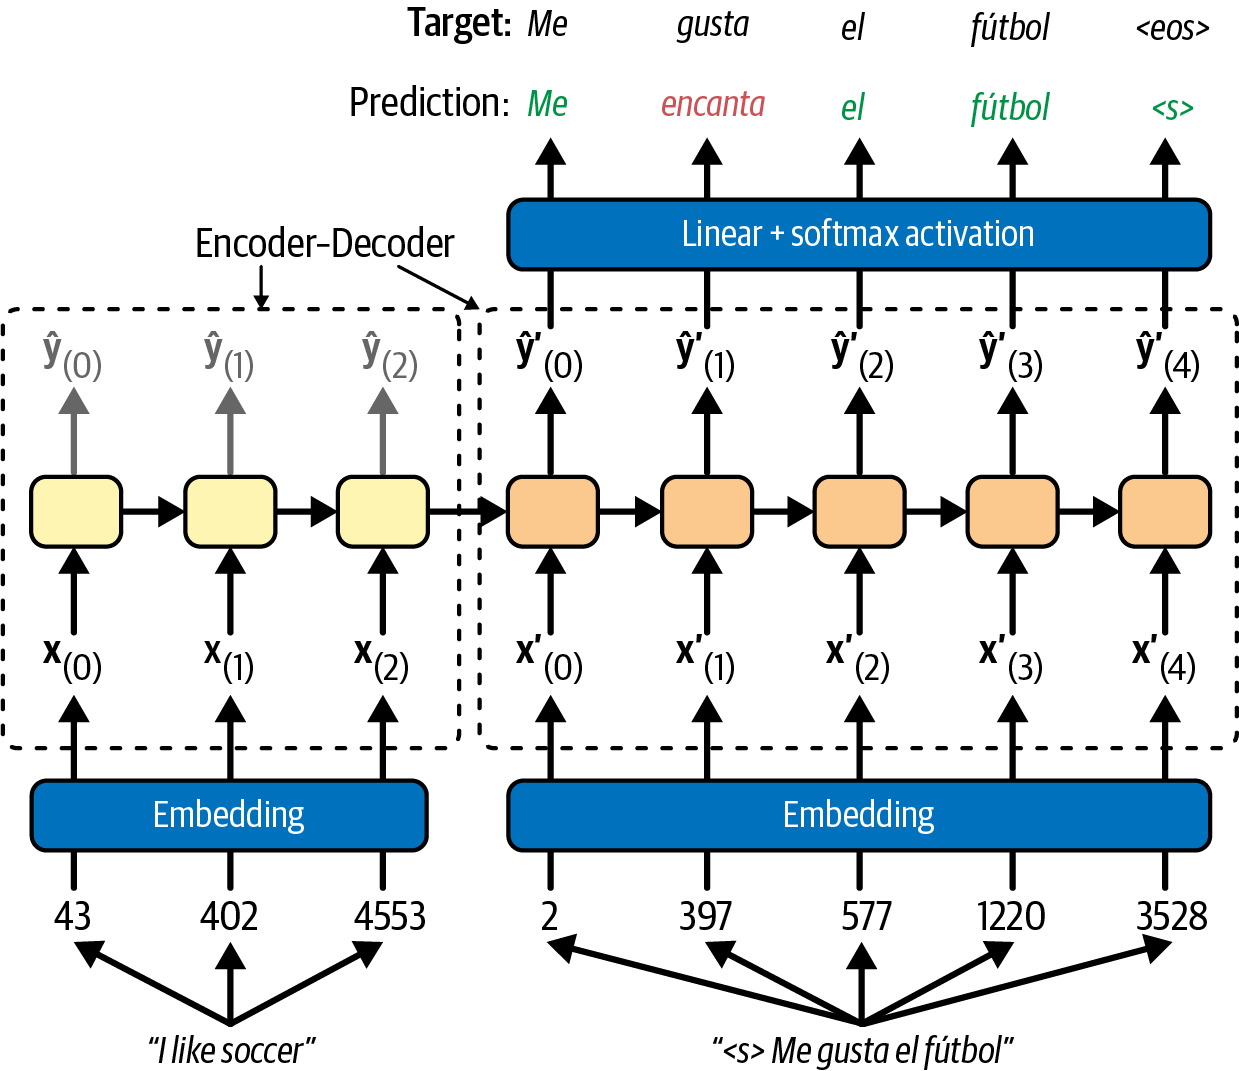

Can use a technique known as teacher forcing to speed up training: even if the model predicts the first word wrong, you give it the correct one when it tries to predict word 2. 

First token: beginning of sequence token, last token the decoder predicts with end of sequence token

At each step, the dense output layer outputs a logit score for each token in the whole vocabulary, which then goes to softmax. Kinda like multiclass classification

In [43]:
nmt_original_valid_set, nmt_test_set = load_dataset(
    path="ageron/tatoeba_mt_train", name="eng-spa",
    split=["validation", "test"])
split = nmt_original_valid_set.train_test_split(train_size=0.8, seed=42)
nmt_train_set, nmt_valid_set = split["train"], split["test"]

Generating test split: 100%|██████████| 24514/24514 [00:00<00:00, 6193552.69 examples/s]


In [44]:
nmt_train_set[0]

{'source_text': 'Tom tried to break up the fight.',
 'target_text': 'Tom trató de disolver la pelea.',
 'source_lang': 'eng',
 'target_lang': 'spa'}

In [45]:
def train_eng_spa():
    for pair in nmt_train_set:
        yield pair["source_text"]
        yield pair["target_text"]

max_len = 256
vocab_size = 10000
nmt_tokenizer = tokenizers.models.BPE(unk_token="<unk>")
nmt_tokenizer = tokenizers.Tokenizer(nmt_tokenizer)
nmt_tokenizer.enable_padding(pad_id=0, pad_token="<pad>")
nmt_tokenizer.enable_truncation(max_length=max_len)
nmt_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.Whitespace()
nmt_tokenizer_trainer = tokenizers.trainers.BpeTrainer(
    vocab_size=vocab_size, special_tokens=["<pad>", "<unk>", "<s>", "</s>"] #beginning and end tokens
)
nmt_tokenizer.train_from_iterator(train_eng_spa(), nmt_tokenizer_trainer)

In [47]:
nmt_tokenizer.encode("Where is the library").ids

[944, 200, 214, 3433]

In [ ]:
# Now we need to make the dataset
# Hold english + spanish tokenized 
# Also needs attn masks

from collections import namedtuple

fields = ["src_token_ids", "src_mask", "tgt_token_ids", "tgt_mask"]
class NmtPair(namedtuple("NmtPairBase", fields)):
    def to(self, device):
        return NmtPair(self.src_token_ids.to(device), self.src_mask.to(device),
                       self.tgt_token_ids.to(device), self.tgt_mask.to(device))
    
# and then the dataloaders
def nmt_collate_fn(batch):
    src_texts = [pair['source_text'] for pair in batch]
    tgt_texts = [f"<s> {pair['target_text']} </s>" for pair in batch]
    # extract all the text, add a start and end token ^
    src_encodings = nmt_tokenizer.encode_batch(src_texts)
    tgt_encodings = nmt_tokenizer.encode_batch(tgt_texts)
    # tokenizes ^
    src_token_ids = torch.tensor([enc.ids for enc in src_encodings])
    tgt_token_ids = torch.tensor([enc.ids for enc in tgt_encodings])
    src_mask = torch.tensor([enc.attention_mask for enc in src_encodings])
    tgt_mask = torch.tensor([enc.attention_mask for enc in tgt_encodings])
    inputs = NmtPair(src_token_ids, src_mask,
                     tgt_token_ids[:, :-1], tgt_mask[:, :-1])
    # NmtPair wrapper holds everything, drops EoS token from input, SoS from output
    labels = tgt_token_ids[:, 1:]
    return inputs, labels

batch_size = 32
nmt_train_loader = DataLoader(nmt_train_set, batch_size=batch_size,
                              collate_fn=nmt_collate_fn, shuffle=True)
nmt_valid_loader = DataLoader(nmt_valid_set, batch_size=batch_size,
                              collate_fn=nmt_collate_fn)
nmt_test_loader = DataLoader(nmt_test_set, batch_size=batch_size,
                             collate_fn=nmt_collate_fn)

The purpose for the EoS/SoS stripping is the teacher forcing setup. At each step the decoder sees the (correct) previous token and the input. No reason to keep EoS in the input because there is nothing after to predict. 

In [ ]:
class NmtModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, pad_id=0, hidden_dim=512, n_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.encoder = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True)
        self.decoder = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True)
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, pair):
        # Embed both input sequences
        src_embeds = self.embed(pair.src_token_ids)
        tgt_embeds = self.embed(pair.tgt_token_ids)
        src_lengths = pair.src_mask.sum(dim=1)
        src_packed = pack_padded_sequence(src_embeds, lengths=src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden_states = self.encoder(src_packed) # English gets encoded
        # The decoder gets the Spanish embeddings and the encoders last hidden states
        outputs, _ = self.decoder(tgt_embeds, hidden_states)
        return self.output(outputs).permute(0,2,1) # Class dim w/ logits is 2nd, which is expected by CrossEntropy and Accuracy
    
vocab_size = nmt_tokenizer.get_vocab_size()
nmt_model = NmtModel(vocab_size).to("cuda")

How does this do teacher forcing?

At training time: tgt_token_ids has the TRUE decoder inputs. The hidden states are from each encoder GRU layers LAST hidden state. Each decoder GRU layer takes in that hidden state and then runs with the correct embeddings, trying to predict the next one. So the only "English" the decoder sees is from the encoder's hidden states.

Logically each time step is just the correct output from one time step ago. Starts at the start token so the model doesn't know any real information at the start.

Remember the GRU outputs just a bunch of hidden states from every "time step" - but we only care about the last time step, the end of the sentence.

In [62]:
def train(model, dataloader, loss_fn, metric, optim, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        epoch_stats = []
        for X_train, y_train in dataloader:
            X_train = X_train.to(device)
            y_train = y_train.to(device)
            y_hat = model(X_train)
            loss = loss_fn(y_hat,y_train)
            optim.zero_grad()
            loss.backward()
            optim.step()
            epoch_stats.append(loss.item())
        print(epoch, sum(epoch_stats)/len(epoch_stats))

loss = nn.CrossEntropyLoss(ignore_index=0)
metric = torchmetrics.Accuracy(task="multiclass", num_classes=vocab_size).to(device)
optim = torch.optim.NAdam(nmt_model.parameters(), lr=.001)
train(nmt_model, nmt_train_loader, loss, metric, optim, 3)

0 3.1301248109343085
1 2.031920518711762
2 1.7148130057478155


In [68]:
def translate(model, src_text, max_length=20, pad_id=0, eos_id=3):
    tgt_text = ""
    token_ids = []
    for index in range(max_length):
        batch, _ = nmt_collate_fn([{"source_text": src_text,
                                    "target_text": tgt_text}])
        with torch.no_grad():
            Y_logits = model(batch.to(device))
            Y_token_ids = Y_logits.argmax(dim=1)  # find the best token IDs
            next_token_id = Y_token_ids[0, index]  # take the last token ID

        next_token = nmt_tokenizer.id_to_token(next_token_id)
        tgt_text += " " + next_token
        if next_token_id == eos_id:
            break
    return tgt_text[:-5]

In [73]:
translate(nmt_model, "Where is the store")

' Dónde está la tienda .'

If you have a huge output vocab, cross entropy loss can be slow. One optimizing trick: sampled softmax. Instead of computing every logit's softmax, compute an approximation based on the correct class, and a random sample of every other class. You need to know the target, so obviously this doesn't work in inference, and pytorch does not implement this.

Or you could do adaptive softmax: split the vocab into frequency based clustered. Most common tokens processed normally, less frequent tokens processed only when necessary. use ``nn.AdaptiveLogSoftmaxWithLoss`

You can also speed up training by using the embedding matrix as the weights of the output layer, which reduces model params by a lot. Add `self.output.weight = self.embed.weight` to the constructor, and get rid of bias with `bias=False`. 

This works because the output layer is reversing all the embedding layer steps - so if the model finds an orthogonal embedding matrix, no need to learn new output weights.

Explained better: embedding matrix goes from vocab space -> embedding space. It is projecting into the vector of embed_dim size. The OUTPUT does the reverse, embed_dim -> vocab size. Matrix identity W W^T = I helps here. You don't need to do the transpose with the weights because nn.Linear will figure it out.

You may notice: the GRU-based model struggles as input length increases. Need to give it more computational power (layers), make encoder bidirectional, or use other techniques.

## Beam Search